# 序列到序列（上）

**Q**: 术语解释
- 源序列和目标序列


**Q**: 结合行文
- 问题的定义是什么？
- 问题的使用场景之一是什么？



## 数据生成

**Q**: 结合行文
- 简化的问题定义是什么？

**Q**: 回答问题
- 这是回归问题还是分类问题？
- 使用什么损失函数？


In [1]:
# 引入
from plots.chapter8 import *
from data_generation.square_sequences import generate_sequences


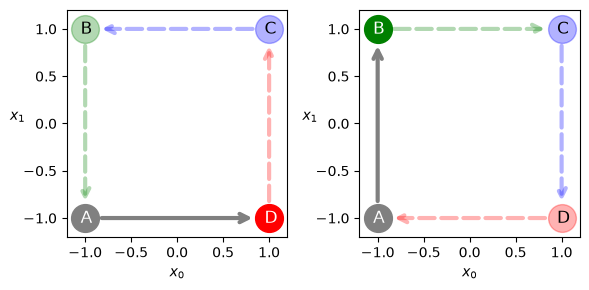

In [2]:
# 问题展示：绘制前两个角，求后两个
fig = counter_vs_clock(binary=False)

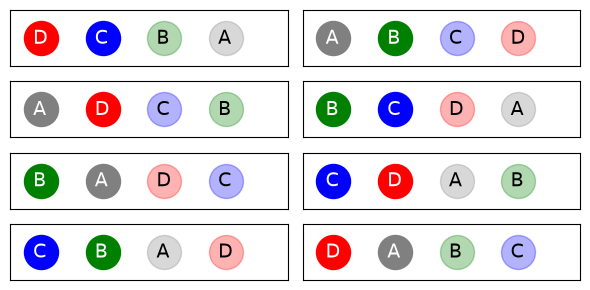

In [3]:
# 问题展示：所有可能的角序列（深色是源序列）
fig = plot_sequences(binary=False, target_len=2)

In [4]:
# 数据生成

points, directions = generate_sequences(n=256, seed=13)

print(points[0],directions[0])

[[-0.97083595  0.96103445]
 [-0.95248123 -1.00723632]
 [ 1.12690581 -0.9742751 ]
 [ 0.83357436  0.98782536]] 0


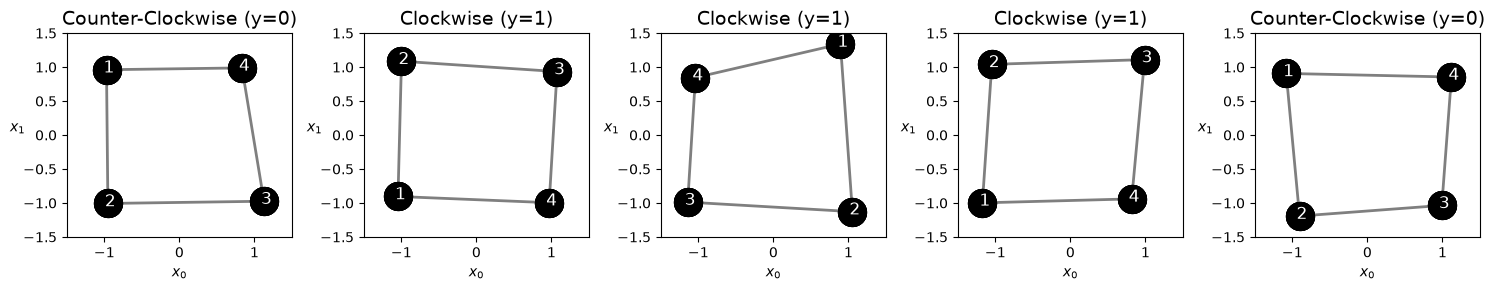

In [5]:
# 可视化数据：绘制顺序

fig = plot_data(points, directions, n_rows=1)

> 现在要处理问题是从源序列预测目标预测（如翻译英文成中文），简化成正方形问题就是给两个点，预测剩下两个点

> 另外这是个回归问题，自然使用MCE均方误差

# 解码器和解码器结构

**Q**: 解释术语
- 编码器和解码器

## 编码器

**Q**: 回顾
- 隐藏状态和序列的关系
- GRU解决了什么问题？

**Q**: 回答问题
- 编码器的目标是什么？

**Q**: 回答问题
- 最终隐藏状态隐藏了什么信息？


In [6]:
# 程序9-1-1: 编码器的结构和用途

class Encoder(nn.Module):
    def __init__(self, n_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.hidden = None
        self.basic_rnn = nn.GRU(self.n_features, self.hidden_dim, batch_first=True)
                
    def forward(self, X):        
        rnn_out, self.hidden = self.basic_rnn(X)
        
        return rnn_out # N, L, F

In [7]:
# 程序9-1-2: 拆分数据（源序列和目标序列）
full_seq = torch.tensor([[-1, -1], [-1, 1], [1, 1], [1, -1]]).float().view(1, 4, 2)
source_seq = full_seq[:, :2] # first two corners
target_seq = full_seq[:, 2:] # last two corners

In [8]:
# 程序9-1-3: 使用编码器

torch.manual_seed(21)
encoder = Encoder(n_features=2, hidden_dim=2)
hidden_seq = encoder(source_seq) # output is N, L, F
hidden_final = hidden_seq[:, -1:]   # 手动取最后隐藏状态
print(hidden_final)

tensor([[[ 0.3105, -0.5263]]], grad_fn=<SliceBackward0>)


> 编码器就是RNN，只因最终隐藏状态是序列的最好代表，它编码了序列的相关信息，如方向等

## 解码器

**Q**: 解释术语
- token词元是什么意思？

**Q**: 回答问题
- 解码器的目标是什么？
- 解码器的计算逻辑是什么？
- 第一个输入应该是什么？
    - 正方形数据情况下
    - 一般情况下


![](images/decoder.png)

In [ ]:
# 程序9-2-1: 解码器的结构和用途 —— 根据编码器隐藏状态逐步生成目标序列
class Decoder(nn.Module):
    def __init__(self, n_features, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.hidden = None
        # 解码器同样使用GRU
        self.basic_rnn = nn.GRU(self.n_features, self.hidden_dim, batch_first=True) 
        # 将隐藏状态映射回原始特征空间（坐标值）
        self.regression = nn.Linear(self.hidden_dim, self.n_features)
        
    def init_hidden(self, hidden_seq):
        # 只需要最终的隐藏状态
        hidden_final = hidden_seq[:, -1:] # N, 1, H
        # 需要序列优先
        self.hidden = hidden_final.permute(1, 0, 2) # 1, N, H                      
        
    def forward(self, X):
        # X 是 N, 1, F
        # 当前输入和隐藏状态传入GRU
        batch_first_output, self.hidden = self.basic_rnn(X, self.hidden) 
        
        # 取最后时间步的输出，映射到目标空间
        last_output = batch_first_output[:, -1:]
        out = self.regression(last_output)
        
        # N, 1, F
        return out.view(-1, 1, self.n_features)               

In [10]:
# 程序9-2-2: 自回归解码 —— 使用解码器逐步预测目标序列的每个坐标
torch.manual_seed(21)
decoder = Decoder(n_features=2, hidden_dim=2)

# 初始隐藏状态将是编码器的最终隐藏状态
decoder.init_hidden(hidden_seq)
# 初始数据点是源序列的最后一个元素
inputs = source_seq[:, -1:]

# 目标序列长度为2，需要预测两个坐标点
target_len = 2
for i in range(target_len):
    print(f'Hidden: {decoder.hidden}')
    out = decoder(inputs)   # 预测坐标
    print(f'Output: {out}\n')
    # 预测坐标是下一步的输入
    inputs = out

Hidden: tensor([[[ 0.3105, -0.5263]]], grad_fn=<PermuteBackward0>)
Output: tensor([[[-0.2339,  0.4702]]], grad_fn=<ViewBackward0>)

Hidden: tensor([[[ 0.3913, -0.6853]]], grad_fn=<StackBackward0>)
Output: tensor([[[-0.0226,  0.4628]]], grad_fn=<ViewBackward0>)



> 解码器利用源序列的编码（最终隐藏状态）然后生成目标序列，只因它的初始输入是源序列的最后一个元素和源序列的编码结果，计算RNN，状态除了继续传递，还利用线性层运行每个单元的输出，将隐藏状态转为预测坐标，预测坐标作为下一个RNN单元的输入

## 教师强制(teacher forcing)

**Q**: 回答问题
- 上述模型存在什么问题？为什么会这样？
- 什么是教师强制？

In [11]:
# 程序9-3-1: 利用实际序列替代预测作为输入

# 初始隐藏状态是编码器的最终隐藏状态
decoder.init_hidden(hidden_seq)
# 初始数据点是源序列的最后一个元素
inputs = source_seq[:, -1:]

target_len = 2
for i in range(target_len):
    print(f'Hidden: {decoder.hidden}')
    out = decoder(inputs) # 预测坐标
    print(f'Output: {out}\n')
    # 完全忽略预测并使用真实数据代替
    inputs = target_seq[:, i:i+1]

Hidden: tensor([[[ 0.3105, -0.5263]]], grad_fn=<PermuteBackward0>)
Output: tensor([[[-0.2339,  0.4702]]], grad_fn=<ViewBackward0>)

Hidden: tensor([[[ 0.3913, -0.6853]]], grad_fn=<StackBackward0>)
Output: tensor([[[0.2265, 0.4529]]], grad_fn=<ViewBackward0>)



In [12]:
# 程序9-3-2: 添加随机性来增加模型的泛化性

# 初始隐藏状态是编码器的最终隐藏状态
decoder.init_hidden(hidden_seq)
# 初始数据点是源序列的最后一个元素
inputs = source_seq[:, -1:]

teacher_forcing_prob = 0.5
target_len = 2
for i in range(target_len):
    print(f'Hidden: {decoder.hidden}')
    out = decoder(inputs)
    print(f'Output: {out}\n')
    # 如果它是教师强制
    if torch.rand(1) <= teacher_forcing_prob:
        # 获取实际元素
        inputs = target_seq[:, i:i+1]
    else:
        # 否则使用最后的预测输出
        inputs = out

Hidden: tensor([[[ 0.3105, -0.5263]]], grad_fn=<PermuteBackward0>)
Output: tensor([[[-0.2339,  0.4702]]], grad_fn=<ViewBackward0>)

Hidden: tensor([[[ 0.3913, -0.6853]]], grad_fn=<StackBackward0>)
Output: tensor([[[-0.0226,  0.4628]]], grad_fn=<ViewBackward0>)



> 教师强制避免了模型开始时因为利用的预测误差太大导致训练困难的问题，只因在解码器步骤不再使用预测输入而是真实输入

> 另外，真实预测中是不会事先知道目标序列的，为了模型的泛化性，教师强制应该添加随机性，有时使用有时使用模型自己的预测

## 编码器+解码器（总结）

**Q**: 回答问题
- 说明从编码器到解码器的信息流

![](./images/encoder_decoder.png)

In [ ]:
# 程序9-4-1: 编码器-解码器联合模型 —— 整合编码器和解码器，支持教师强制训练
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, input_len, target_len, teacher_forcing_prob=0.5):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.input_len = input_len
        self.target_len = target_len
        self.teacher_forcing_prob = teacher_forcing_prob
        self.outputs = None
        
    def init_outputs(self, batch_size):
        # 获取模型设备，确保输出张量在同一设备上
        device = next(self.parameters()).device
        # N, L (目标), F
        self.outputs = torch.zeros(batch_size, 
                              self.target_len, 
                              self.encoder.n_features).to(device)
    
    def store_output(self, i, out):
        # 存储输出
        self.outputs[:, i:i+1, :] = out
        
    def forward(self, X):               
        # 拆分源序列和目标序列中的数据
        # 目标序列在测试模式下将为空
        # N, L, F
        source_seq = X[:, :self.input_len, :]
        target_seq = X[:, self.input_len:, :]
        self.init_outputs(X.shape[0])        
        
        # 编码源序列，得到各时间步隐藏状态
        # 预测编码器 N, L, F
        hidden_seq = self.encoder(source_seq)
        # 输出格式为 N, L, H
        # 用编码器最终隐藏状态初始化解码器
        self.decoder.init_hidden(hidden_seq)
        
        # 编码器的最后一个输入也是解码器的第一个输入
        dec_inputs = source_seq[:, -1:, :]
        
        # 生成和目标序列长度一样多的输出
        for i in range(self.target_len):
            # 解码器的输出是 N, 1, F
            out = self.decoder(dec_inputs)
            self.store_output(i, out)
            
            prob = self.teacher_forcing_prob
            # 在测试中目标序列是未知的
            # 所以不能强制使用教师强制
            if not self.training:
                prob = 0
                
            # 如果是 teacher forcing
            if torch.rand(1) <= prob:
                # 获取实际元素
                dec_inputs = target_seq[:, i:i+1, :]
            else:
                # 否则使用最后的预测输出
                dec_inputs = out
            
        return self.outputs

In [14]:
# 程序9-4-2: 
encdec = EncoderDecoder(encoder, decoder, input_len=2, target_len=2, teacher_forcing_prob=1.0)
encdec.train()
encdec(full_seq)

tensor([[[-0.2339,  0.4702],
         [ 0.2265,  0.4529]]], grad_fn=<CopySlices>)

In [15]:
# 程序9-4-3: 
encdec.eval()
encdec(source_seq)

tensor([[[-0.2339,  0.4702],
         [-0.0226,  0.4628]]], grad_fn=<CopySlices>)

## 数据准备

In [16]:
# 引入
from torch.utils.data import DataLoader, TensorDataset

In [17]:
points, directions = generate_sequences(n=256, seed=13)
full_train = torch.as_tensor(points).float()
target_train = full_train[:, 2:]

C:\Users\a7183\AppData\Local\Temp\ipykernel_5524\1483810553.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  full_train = torch.as_tensor(points).float()


In [18]:
test_points, test_directions = generate_sequences(seed=19)
full_test = torch.as_tensor(test_points).float()
source_test = full_test[:, :2]
target_test = full_test[:, 2:]

In [19]:
train_data = TensorDataset(full_train, target_train)
test_data = TensorDataset(source_test, target_test)

generator = torch.Generator()
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, generator=generator)
test_loader = DataLoader(test_data, batch_size=16)

## 模型配置

In [20]:
# 引入

from stepbystep.v4 import StepByStep
import torch.optim as optim

In [21]:
torch.manual_seed(23)
encoder = Encoder(n_features=2, hidden_dim=2)
decoder = Decoder(n_features=2, hidden_dim=2)
model = EncoderDecoder(encoder, decoder, input_len=2, target_len=2, teacher_forcing_prob=0.5)
loss = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 模型训练

In [22]:
sbs_seq = StepByStep(model, loss, optimizer)
sbs_seq.set_loaders(train_loader, test_loader)
sbs_seq.train(100)

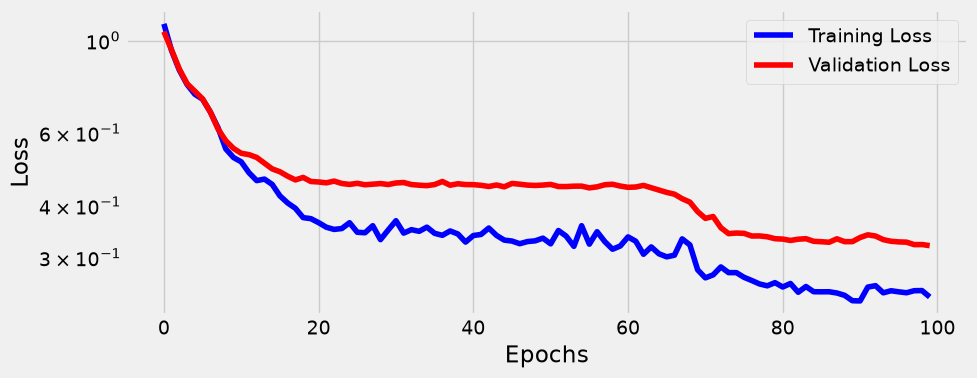

In [23]:
fig = sbs_seq.plot_losses()

## 可视化预测

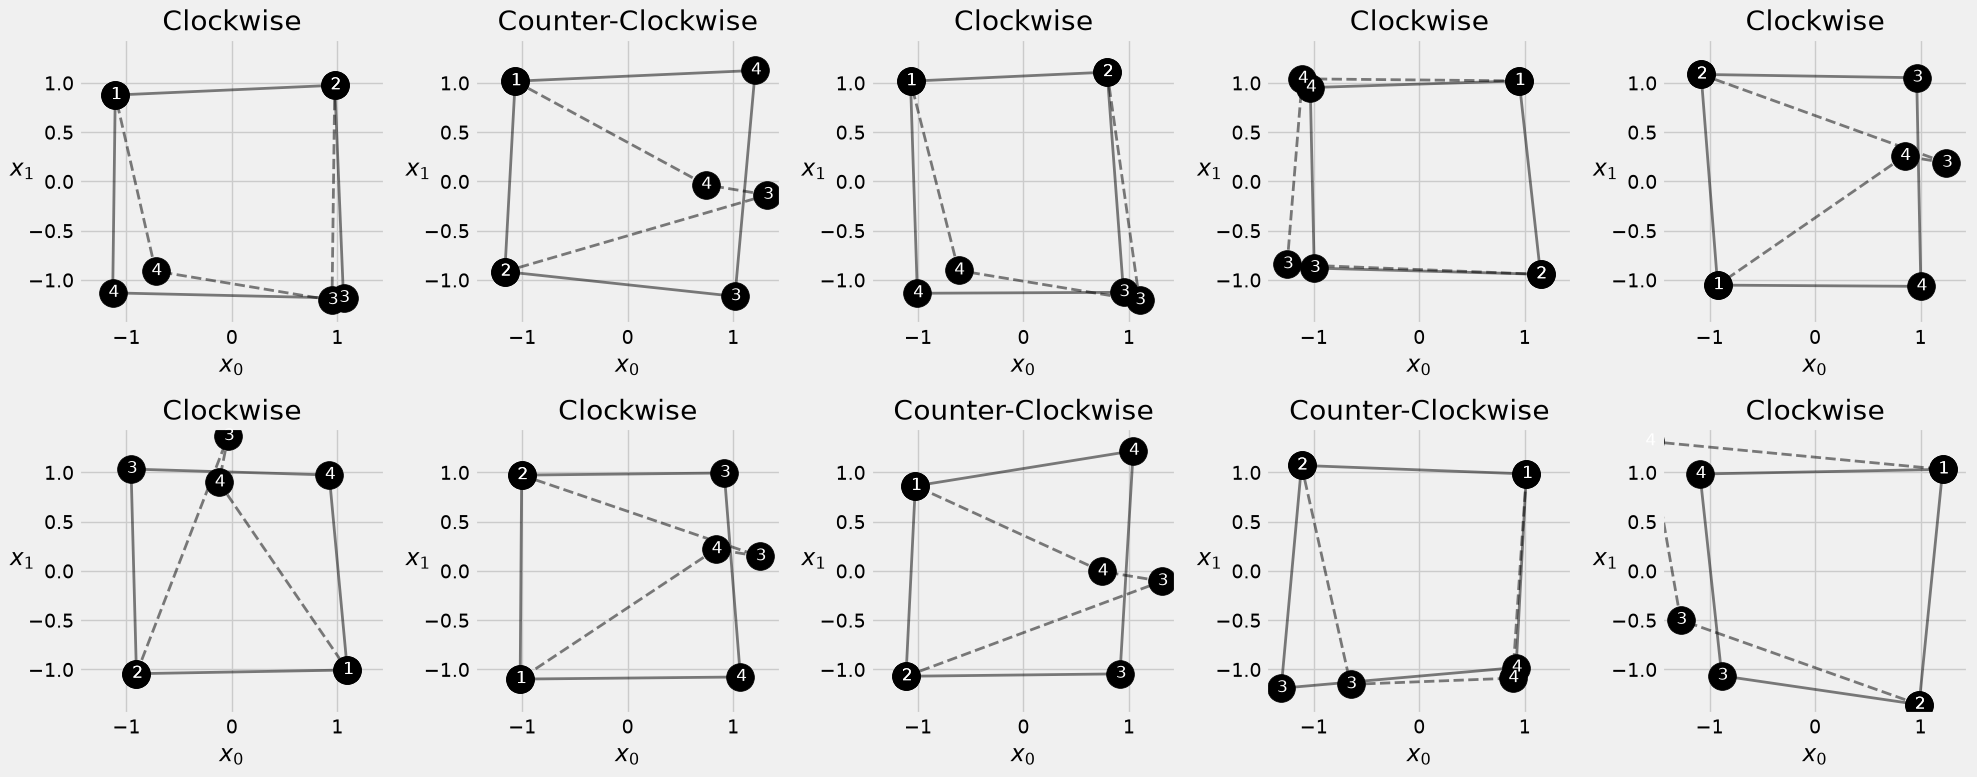

In [24]:
from plots.chapter9 import *
fig = sequence_pred(sbs_seq, full_test, test_directions)